In [126]:
from sklearn.datasets import fetch_openml
import numpy as np

In [127]:
mnist = fetch_openml("mnist_784", version = 1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [128]:
x, y = mnist["data"], mnist["target"]
x.shape

(70000, 784)

In [129]:
y.shape

(70000,)

In [130]:
# looking at a digit, by simply converting it into a 28*28 array

import matplotlib as mpl
import matplotlib.pyplot as plt

In [131]:
some_digit = x.iloc[0].values
some_digit_image = some_digit.reshape(28,28)

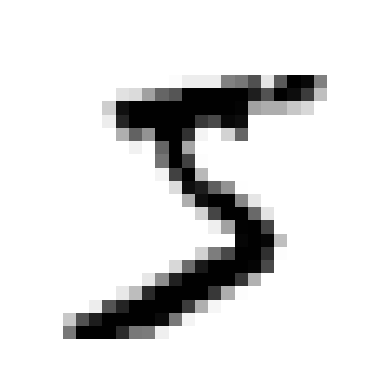

In [132]:
plt.imshow(some_digit_image, cmap = mpl.cm.binary, interpolation="nearest")
plt.axis("off")
plt.show()

In [133]:
def plot_digits(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    # This is equivalent to n_rows = ceil(len(instances) / images_per_row):
    n_rows = (len(instances) - 1) // images_per_row + 1

    # Append empty images to fill the end of the grid, if needed:
    n_empty = n_rows * images_per_row - len(instances)
    padded_instances = np.concatenate([instances, np.zeros((n_empty, size * size))], axis=0)

    # Reshape the array so it's organized as a grid containing 28×28 images:
    image_grid = padded_instances.reshape((n_rows, images_per_row, size, size))

    # Combine axes 0 and 2 (vertical image grid axis, and vertical image axis),
    # and axes 1 and 3 (horizontal axes). We first need to move the axes that we
    # want to combine next to each other, using transpose(), and only then we
    # can reshape:
    big_image = image_grid.transpose(0, 2, 1, 3).reshape(n_rows * size,
                                                         images_per_row * size)
    # Now that we have a big image, we just need to show it:
    plt.imshow(big_image, cmap = mpl.cm.binary, **options)
    plt.axis("off")

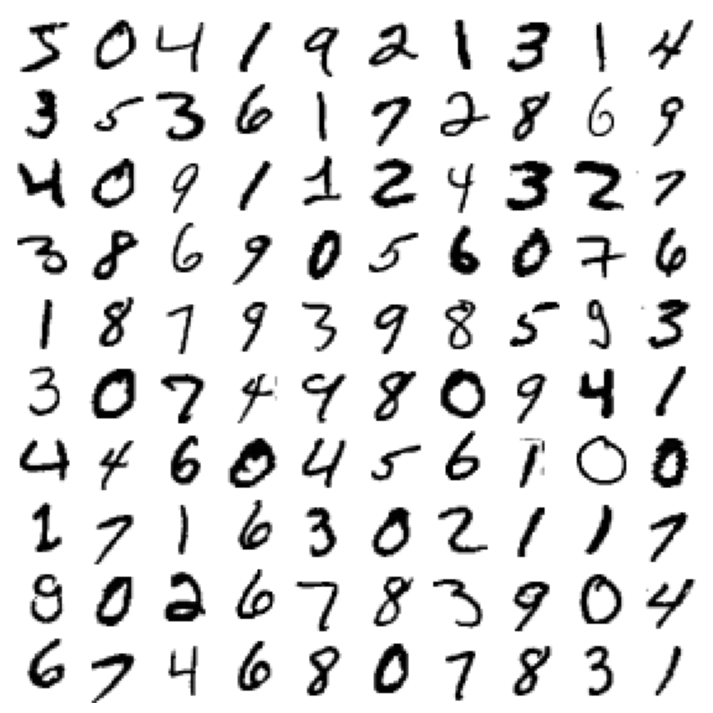

In [134]:
plt.figure(figsize=(9,9))
example_images = x[:100]
plot_digits(example_images, images_per_row=10)
plt.show()

In [135]:
y[0]

'5'

### Binary Classifier

In [136]:
# y is a string, as we can see above
# let's just cast it to int

y = y.astype(np.uint8)

### Creting Train and test set

In [141]:
x_train, x_test, y_train, y_test = x[:60000], x[60000:], y[:60000], y[60000:]

In [13]:
# let's just try to identify one digit i.e. 5

y_train_5 = (y_train==5)
y_test_5 = (y_test==5)

In [14]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state = 45)
sgd_clf.fit(x_train, y_train_5)

SGDClassifier(random_state=45)

In [15]:
sgd_clf.predict([some_digit])

C:\Users\satya\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([ True])

In [16]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

In [17]:
# skfolds = StratifiedKFold(n_splits = 3)

# for train_index, test_index in skfolds.split(x_train, y_train_5):
#     clone_clf = clone(sgd_clf)
#     x_train_folds = x_train.iloc[train_index]
#     y_train_folds = y_train_5.iloc[train_index]
#     x_test_fold = x_train.iloc[test_index]
#     y_test_fold = y_test_5.iloc[test_index]

## DecisionTree Regressor

In [18]:
from sklearn.base import BaseEstimator
from sklearn.model_selection import cross_val_score

In [19]:
from sklearn.tree import DecisionTreeRegressor
class_reg = DecisionTreeRegressor()
cross_val_score(class_reg, x_train, y_train_5, cv=3, scoring="accuracy")

array([0.9723 , 0.97165, 0.9711 ])

### A Dumb Classifier
#### This predicts every digit as "not-5"

In [20]:
class Never5Classifier(BaseEstimator):
    def fit(self, x, y=None):
        pass
    def predict(self, x):
        return np.zeros((len(x),1), dtype=bool)

In [21]:
never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, x_train, y_train_5, cv=3, scoring="accuracy")

array([0.91125, 0.90855, 0.90915])

## Confusion Matrix

In [22]:
from sklearn.model_selection import cross_val_predict

In [23]:
y_train_pred = cross_val_predict(sgd_clf, x_train, y_train_5, cv=3)

In [24]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5, y_train_pred)

array([[53964,   615],
       [ 1399,  4022]], dtype=int64)

In [25]:
# how a perfect classifier would have classified

y_train_perfect_predictions = y_train_5
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]], dtype=int64)

### Precision and Recall

In [26]:
from sklearn.metrics import precision_score, recall_score

In [27]:
precision_score(y_train_5, y_train_pred)

0.867371145136942

In [28]:
recall_score(y_train_5, y_train_pred)

0.7419295332964397

In [29]:
from sklearn.metrics import f1_score

In [30]:
f1_score(y_train_5, y_train_pred)

0.7997613839729568

### Defining the decision_function, to control the threshold

In [31]:
y_score = sgd_clf.decision_function([some_digit])
y_score

C:\Users\satya\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([5767.34385763])

In [32]:
threshold=0
y_some_digit_pred = (y_score>threshold)
y_some_digit_pred

array([ True])

In [33]:
threshold=8000
y_some_digit_pred = (y_score>threshold)
y_some_digit_pred

array([False])

### Finding the suitable Threshold

In [34]:
y_scores = cross_val_predict(sgd_clf, x_train, y_train_5, cv=3, method="decision_function")

In [35]:
y_scores

array([  2336.57850459, -18828.61412923, -34171.9625947 , ...,
         7693.97088857,  -6636.21165362, -11215.81905316])

In [36]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

In [37]:
# our_threshold = 8000
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], label="Preciison", linestyle="--")
    plt.plot(thresholds, recalls[:-1], label="Recall")
    plt.grid()
    # plt.axvline(x=our_threshold, linestyle='--', color='gray', alpha=0.5)
    plt.xlabel("Threshold")
    plt.legend()

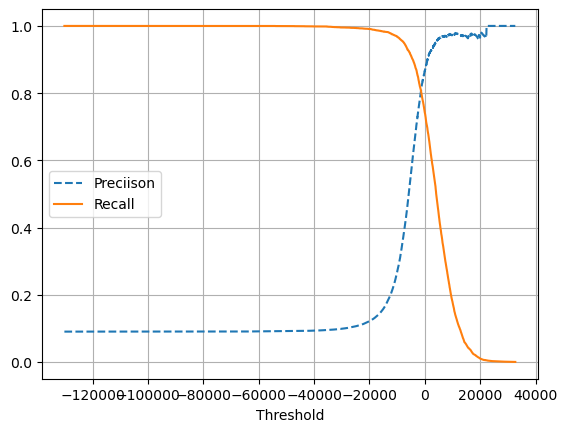

In [38]:
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

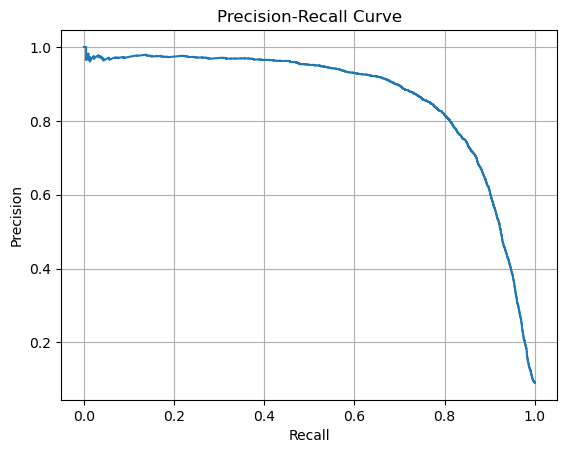

In [39]:
plt.plot(recalls, precisions)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid()
plt.show()

In [40]:
threshold_90_precision = thresholds[np.argmax(precisions >= 0.9)]

In [41]:
y_train_pred_90 = (y_scores >= threshold_90_precision)

In [42]:
precision_score(y_train_5, y_train_pred_90)

0.9001203369434416

In [43]:
recall_score(y_train_5, y_train_pred_90)

0.6899096107729201

In [44]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

In [45]:
def plt_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0,1], [0,1], "k--")
    plt.grid()
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")

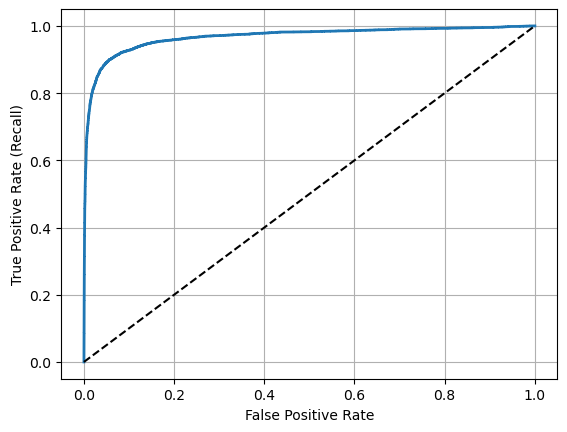

In [46]:
plt_roc_curve(fpr, tpr)
plt.show()

In [47]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores)

0.9674493047871298

In [48]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, x_train, y_train_5, cv = 3, method= "predict_proba")

In [49]:
y_probas_forest

array([[0.11, 0.89],
       [0.99, 0.01],
       [0.96, 0.04],
       ...,
       [0.02, 0.98],
       [0.92, 0.08],
       [0.94, 0.06]])

In [50]:
y_scores_forest = y_probas_forest[:, 1]
fpr_forest, tpr_forest, threshold_forest = roc_curve(y_train_5, y_scores_forest)

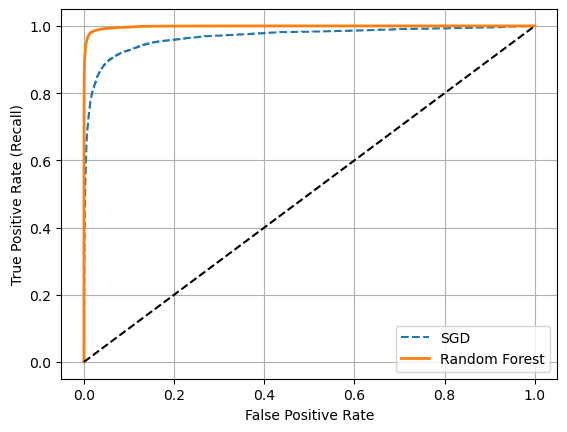

In [51]:
plt.plot(fpr, tpr, "--", label="SGD")
plt_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.legend(loc="lower right")
plt.show()

In [52]:
roc_auc_score(y_train_5, y_scores_forest)

0.9983436731328145

In [53]:
y_pred_forest = (y_scores_forest > 0.5)

In [54]:
precision_score(y_train_5, y_pred_forest)

0.9905083315756169

In [55]:
recall_score(y_train_5, y_pred_forest)

0.8662608374838591

In [56]:
f1_score(y_train_5, y_pred_forest)

0.9242275142688448

In [59]:
sgd_clf.fit(x_train, y_train)
sgd_clf.predict([some_digit])

C:\Users\satya\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([5], dtype=uint8)

In [61]:
#checking whats under the hood
some_digit_scores = sgd_clf.decision_function([some_digit])
some_digit_scores

C:\Users\satya\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([[-25265.53577173, -29221.35047615,  -7232.23445534,
          1001.79972385, -18336.16413418,   5563.83291989,
        -18395.66570862, -14555.73200795,  -7173.49758217,
        -11164.50090867]])

In [62]:
np.argmax(some_digit_scores)

5

In [63]:
sgd_clf.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [64]:
forest_clf.fit(x_train, y_train)
forest_clf.predict([some_digit])

C:\Users\satya\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([5], dtype=uint8)

In [65]:
forest_clf.predict_proba([some_digit])

C:\Users\satya\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([[0.  , 0.  , 0.01, 0.08, 0.  , 0.9 , 0.  , 0.  , 0.  , 0.01]])

In [66]:
cross_val_score(sgd_clf, x_train, y_train, cv=3, scoring="accuracy")

array([0.8861, 0.8701, 0.8777])

In [67]:
cross_val_score(forest_clf, x_train, y_train, cv=3, scoring="accuracy")

array([0.9646 , 0.96255, 0.9666 ])

In [68]:
# using scaled data for sgd classifier
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train.astype(np.float64))
cross_val_score(sgd_clf, x_train_scaled, y_train, cv=3, scoring="accuracy")

array([0.90025, 0.8979 , 0.9012 ])

In [69]:
y_train_pred = cross_val_predict(sgd_clf, x_train_scaled, y_train, cv=3)
conf_mat = confusion_matrix(y_train, y_train_pred)
conf_mat

array([[5587,    0,   23,    6,    8,   43,   36,    6,  213,    1],
       [   0, 6403,   39,   26,    4,   44,    4,    8,  202,   12],
       [  27,   28, 5264,   94,   73,   27,   68,   37,  333,    7],
       [  23,   18,  119, 5248,    2,  206,   27,   41,  374,   73],
       [  11,   14,   51,    9, 5198,   11,   38,   27,  312,  171],
       [  27,   16,   32,  169,   54, 4464,   78,   18,  500,   63],
       [  31,   16,   45,    2,   42,   97, 5558,    4,  122,    1],
       [  20,   10,   52,   30,   48,   12,    3, 5695,  171,  224],
       [  18,   66,   47,   91,    3,  125,   25,   10, 5421,   45],
       [  22,   19,   30,   66,  119,   33,    1,  176,  334, 5149]],
      dtype=int64)

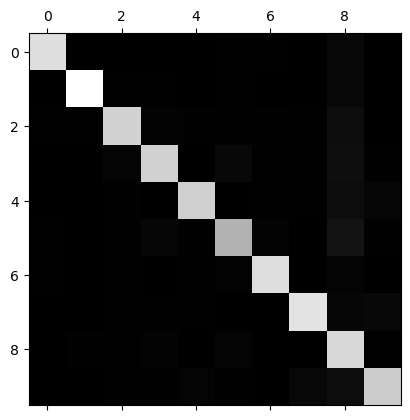

In [70]:
plt.matshow(conf_mat, cmap = plt.cm.gray)
plt.show()

In [71]:
row_sums = conf_mat.sum(axis = 1, keepdims=True)
norm_conf_mat = conf_mat/row_sums

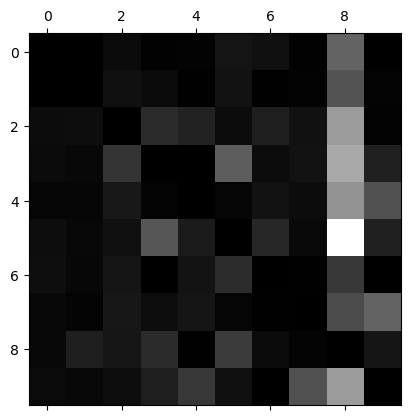

In [72]:
np.fill_diagonal(norm_conf_mat, 0)
plt.matshow(norm_conf_mat, cmap = plt.cm.gray)
plt.show()

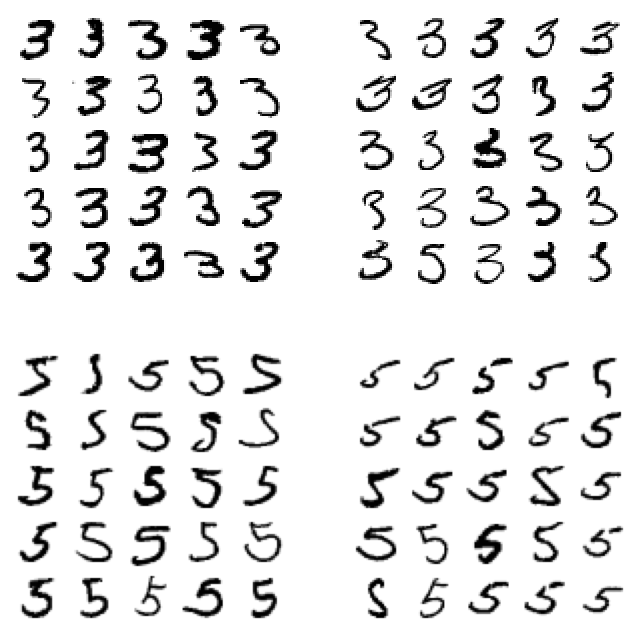

In [73]:
# Lets plot examples for 3s and 5s
cl_a, cl_b = 3, 5
x_aa = x_train[(y_train == cl_a) & (y_train_pred == cl_a)]
x_ab = x_train[(y_train == cl_a) & (y_train_pred == cl_b)]
x_ba = x_train[(y_train == cl_b) & (y_train_pred == cl_a)]
x_bb = x_train[(y_train == cl_b) & (y_train_pred == cl_b)]
plt.figure(figsize=(8,8))
plt.subplot(221); plot_digits(x_aa[:25], images_per_row=5)
plt.subplot(222); plot_digits(x_ab[:25], images_per_row=5)
plt.subplot(223); plot_digits(x_ba[:25], images_per_row=5)
plt.subplot(224); plot_digits(x_bb[:25], images_per_row=5)
plt.show()

### Creating Multilabel Classifier

In [74]:
from sklearn.neighbors import KNeighborsClassifier
y_train_large = (y_train>=7)
y_train_odd = (y_train % 2  == 1)

y_multilabel = np.c_[y_train_large, y_train_odd]

In [75]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(x_train, y_multilabel)

knn_clf.predict([some_digit])

C:\Users\satya\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([[False,  True]])

In [76]:
y_train_knn_predict = cross_val_predict(knn_clf, x_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_predict, average="macro")

0.9764102655606048

### Multioutput Classification 
## Removing noise

In [77]:
noise = np.random.randint(0,100, (len(x_train), 784))
x_train_mod = x_train + noise
noise = np.random.randint(0,100, (len(x_test), 784))
x_test_mod = x_test + noise

y_train_mod = x_train
y_test_mod = x_test

In [79]:
def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap = mpl.cm.binary,
               interpolation="nearest")
    plt.axis("off")

In [80]:
x_train_mod_array = x_train_mod.to_numpy()
y_train_mod_array = y_train_mod.to_numpy()
x_test_mod_array = x_test_mod.to_numpy()
y_test_mod_array = y_test_mod.to_numpy()

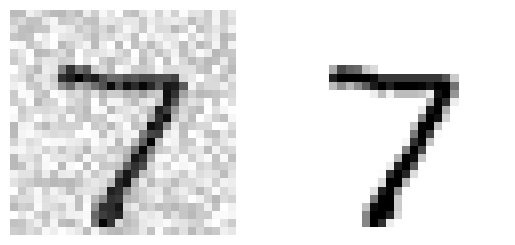

In [81]:
some_index = 0
plt.subplot(121)
plot_digit(x_test_mod_array[some_index])
plt.subplot(122)
plot_digit(y_test_mod_array[some_index])

C:\Users\satya\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


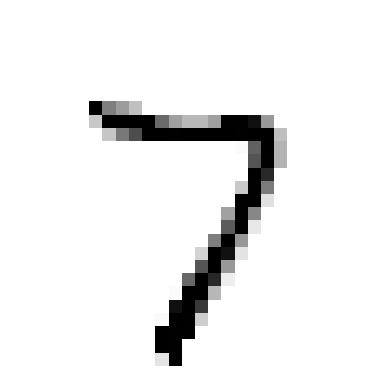

In [105]:
knn_clf.fit(x_train_mod, y_train_mod)
clean_data = knn_clf.predict([x_test_mod.iloc[some_index]])
plot_digit(clean_data)

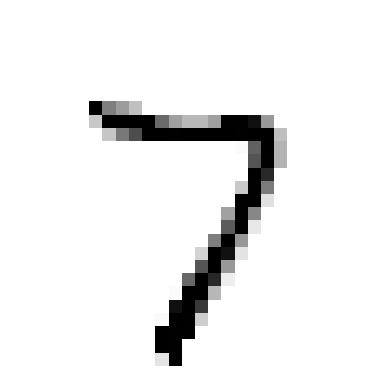

In [97]:
knn_clf.fit(x_train_mod_array, y_train_mod_array)
clean_digit = knn_clf.predict([x_test_mod_array[some_index]])
plot_digit(clean_digit)

### Shifting of images

In [108]:
from sklearn.model_selection import GridSearchCV
param_grid={
    "weights":["uniform", "distance"],
    "n_neighbors":[3,4,5]
}

In [109]:
knn_clf = KNeighborsClassifier()
grid_search = GridSearchCV(knn_clf, param_grid, cv=5, verbose=3)
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 1/5] END ....n_neighbors=3, weights=uniform;, score=0.972 total time=  44.2s
[CV 2/5] END ....n_neighbors=3, weights=uniform;, score=0.971 total time=  40.5s
[CV 3/5] END ....n_neighbors=3, weights=uniform;, score=0.969 total time=  41.0s
[CV 4/5] END ....n_neighbors=3, weights=uniform;, score=0.969 total time=  40.5s
[CV 5/5] END ....n_neighbors=3, weights=uniform;, score=0.970 total time=  40.4s
[CV 1/5] END ...n_neighbors=3, weights=distance;, score=0.972 total time=  39.0s
[CV 2/5] END ...n_neighbors=3, weights=distance;, score=0.972 total time=  39.2s
[CV 3/5] END ...n_neighbors=3, weights=distance;, score=0.970 total time=  39.3s
[CV 4/5] END ...n_neighbors=3, weights=distance;, score=0.970 total time=  38.0s
[CV 5/5] END ...n_neighbors=3, weights=distance;, score=0.971 total time=  39.2s
[CV 1/5] END ....n_neighbors=4, weights=uniform;, score=0.969 total time=  57.5s
[CV 2/5] END ....n_neighbors=4, weights=uniform;,

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 4, 5],
                         'weights': ['uniform', 'distance']},
             verbose=3)

In [110]:
grid_search.best_params_

{'n_neighbors': 4, 'weights': 'distance'}

In [113]:
grid_search.best_score_

0.9716166666666666

In [117]:
from sklearn.metrics import accuracy_score
y_pred = grid_search.predict(x_test)
accuracy_score(y_test, y_pred)

0.9714

In [204]:
from scipy.ndimage.interpolation import shift

C:\Users\satya\AppData\Local\Temp\ipykernel_1348\987197595.py:1: DeprecationWarning: Please import `shift` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.interpolation import shift


In [205]:
def shift_image(image,dy,dx):
    image = image.reshape(28*28)
    shifted_image = shift(image, dy,dx, cval=10, mode="constant")
    return shifted_image.reshape([-1])

In [206]:
x_train.iloc[5]

pixel1      0
pixel2      0
pixel3      0
pixel4      0
pixel5      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Name: 5, Length: 784, dtype: int64

In [203]:
image = x_train.iloc[5]
shifted_down = shift_image(image, 0, 5)
shifted_left = shift_image(image, -5, 0)
# shifted_right = shift_image(image, 5, 0)
# shifted_up = shift_image(image, 0, -5)

# plt.figure(figsize=(15,5))
# plt.subplot(131)
# plt.title("Original", fontsize=14)
# plt.imshow(image.reshape(28, 28), interpolation="nearest", cmap="Greys")
# plt.subplot(132)
# plt.title("Shifted down", fontsize=14)
# plt.imshow(shifted_down.reshape(28, 28), interpolation="nearest", cmap="Greys")
# plt.subplot(133)
# plt.title("Shifted left", fontsize=14)
# plt.imshow(shifted_left.reshape(28, 28), interpolation="nearest", cmap="Greys")
# # plt.subplot(134)
# # plt.title("Shifted right", fontsize=14)
# # plt.imshow(shifted_right.reshape(28, 28), interpolation="nearest", cmap="Greys")
# # plt.subplot(135)
# # plt.title("Shifted up", fontsize=14)
# # plt.imshow(shifted_up.reshape(28, 28), interpolation="nearest", cmap="Greys")

# plt.show()

AttributeError: 'Series' object has no attribute 'reshape'